# Importing Required Libraries

In this section, we import the main Python libraries used for data analysis, visualization, and econometric modeling.

The following libraries are used:

- **pandas** — for working with tabular data
- **numpy** — for numerical computations
- **matplotlib** — for plotting graphs
- **seaborn** — for statistical visualization
- **statsmodels** — for time series modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Oil Price Data

The first dataset contains monthly global oil prices (Brent).

Oil prices are an important macroeconomic factor for Kazakhstan because the country's economy is highly dependent on oil exports.

The dataset includes:

- observation date
- oil price in USD per barrel

In [2]:
oil = pd.read_csv("POILBREUSDM.csv")

oil = oil.rename(columns={
    "observation_date": "Date",
    "POILBREUSDM": "oil_price"
})

oil["Date"] = pd.to_datetime(oil["Date"])

oil.head()

,Date,oil_price
0,2008-01-01,92.091739
1,2008-02-01,94.722381
2,2008-03-01,103.161905
3,2008-04-01,110.033182
4,2008-05-01,123.862273


# Loading Exchange Rate Data

The exchange rate of the US dollar to the Kazakhstani tenge (USD/KZT) plays an important role in inflation dynamics.

Currency depreciation often leads to higher import prices and increased inflation.

In [3]:
usd = pd.read_excel("Официальные (рыночные) курсы валют.xlsx")

usd["Date"] = pd.to_datetime(usd["Date"], dayfirst=True)

usd_monthly = usd.resample("M", on="Date").mean().reset_index()

usd_monthly = usd_monthly.rename(columns={"USD": "usd_kzt"})

usd_monthly.head()

C:\Users\user\AppData\Local\Temp\ipykernel_20192\2283266804.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  usd_monthly = usd.resample("M", on="Date").mean().reset_index()


,Date,USD_quant,usd_kzt
0,2008-01-31,1.0,120.352258
1,2008-02-29,1.0,120.322414
2,2008-03-31,1.0,120.644194
3,2008-04-30,1.0,120.510333
4,2008-05-31,1.0,120.551290


# Loading CPI Data

The Consumer Price Index (CPI) reflects changes in the price level of goods and services.

In this analysis we use the CPI indicator for **All goods and services**, which represents the overall inflation level in the economy.

In [4]:
cpi = pd.read_excel("13 groups.xls", skiprows=4)

cpi.head()

,of previous month,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,All goods and services,1.1,0.8,0.6,0.9,1.0,1.2,0.9,0.8,0.6,0.6,0.4,0.2
1,Food and non-alcoholic beverages,1.7,1.2,0.9,1.1,1.5,1.9,0.6,-0.1,0.1,0.6,0.8,0.3
2,"Alcoholic beverages, tobacco",0.7,0.6,1.1,0.7,0.8,0.8,0.3,0.4,0.2,0.6,0.5,2.0
3,Clothing and footwear,0.9,0.8,0.6,0.6,0.4,0.5,0.3,0.4,0.5,0.8,1.0,1.1
4,"Housing, water, electricity, gas and other fuels",0.3,0.2,0.0,0.5,0.5,0.1,0.8,2.5,1.5,1.2,1.5,-0.3


# Transforming CPI Data

The CPI dataset stores months as columns.

To prepare the data for analysis, we convert the table into a structured format where each row represents one month and its CPI value.

In [5]:
years = range(2008, 2026)

cpi_list = []

for year in years:

    sheet = f"monthly {year}"

    df = pd.read_excel("13 groups.xls", sheet_name=sheet, skiprows=4)

    row = df.iloc[0,1:13]   # строка All goods and services

    for month in range(12):

        cpi_list.append({
            "Date": f"{year}-{month+1:02d}-01",
            "cpi": row.iloc[month]
        })

cpi_final = pd.DataFrame(cpi_list)

cpi_final["Date"] = pd.to_datetime(cpi_final["Date"])

cpi_final.head()

,Date,cpi
0,2008-01-01,1.1
1,2008-02-01,0.8
2,2008-03-01,0.6
3,2008-04-01,0.9
4,2008-05-01,1.0


# CPI Data Preparation

The CPI dataset was extracted from the official statistics dataset.

The monthly CPI values for **All goods and services** were selected as the main indicator of inflation.

The dataset was transformed into a time-series format where each observation represents the CPI value for a specific month.

# Merging Macroeconomic Indicators

To analyze the determinants of inflation in Kazakhstan, three datasets are merged:

• Global oil price (Brent)  
• Exchange rate (USD/KZT)  
• Consumer Price Index (CPI)

The datasets are merged using the Date column.

In [6]:
oil_monthly = oil.resample("M", on="Date").mean().reset_index()

C:\Users\user\AppData\Local\Temp\ipykernel_20192\3063316489.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  oil_monthly = oil.resample("M", on="Date").mean().reset_index()


In [7]:
cpi_final["Date"] = pd.to_datetime(cpi_final["Date"])
cpi_final["Date"] = cpi_final["Date"] + pd.offsets.MonthEnd(0)


In [8]:
data = oil_monthly.merge(usd_monthly, on="Date", how="inner")
data = data.merge(cpi_final, on="Date", how="inner")

data = data[["Date", "oil_price", "usd_kzt", "cpi"]]

data.head()

,Date,oil_price,usd_kzt,cpi
0,2008-01-31,92.091739,120.352258,1.1
1,2008-02-29,94.722381,120.322414,0.8
2,2008-03-31,103.161905,120.644194,0.6
3,2008-04-30,110.033182,120.510333,0.9
4,2008-05-31,123.862273,120.551290,1.0


In [9]:
data.shape

(216, 4)

# Dataset Overview

The final dataset contains monthly observations from 2001 to 2025.

The dataset includes the following macroeconomic variables:

• Oil price/Energetics (Brent)
• Unemployment  
• Exchange rate (USD/KZT)  
• Consumer Price Index (CPI)

These variables will be used to analyze inflation dynamics in Kazakhstan.

In [10]:
data.describe()

,Date,oil_price,usd_kzt,cpi
count,216,216.000000,216.000000,216.000000
mean,2017-01-14 04:06:40,77.949756,300.331584,0.697222
min,2008-01-31 00:00:00,26.848636,119.668000,-0.100000
25%,2012-07-23 06:00:00,59.915178,150.512024,0.400000
50%,2017-01-15 12:00:00,75.194000,331.726774,0.600000
75%,2021-07-07 18:00:00,98.078409,428.114575,0.900000
max,2025-12-31 00:00:00,133.585217,540.748667,5.200000
std,NaN,24.153477,137.793502,0.563041


# Descriptive Statistics

Descriptive statistics summarize the main characteristics of the dataset, including the mean, standard deviation, and range of each variable.

# Correlation Analysis

Correlation analysis is used to examine the relationships between inflation and macroeconomic variables such as oil prices and exchange rates.

In [11]:
data.drop(columns="Date").corr()

,oil_price,usd_kzt,cpi
oil_price,1.00000,-0.389760,0.018370
usd_kzt,-0.38976,1.000000,0.240674
cpi,0.01837,0.240674,1.000000


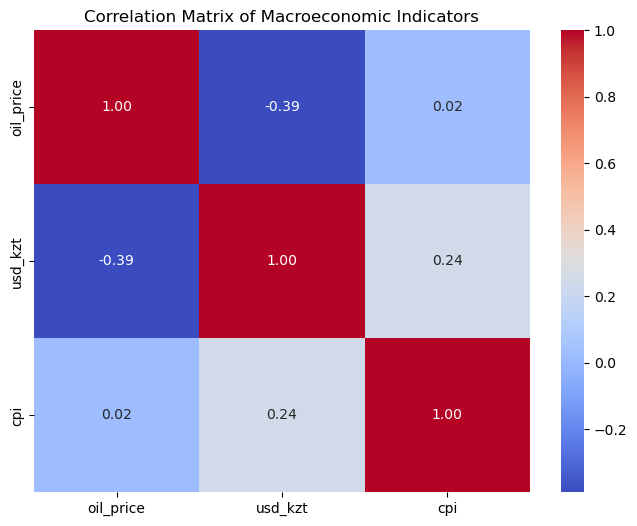

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    data.drop(columns="Date").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Macroeconomic Indicators")

plt.show()

# Time Series Preparation

Before building a forecasting model, the dataset is converted into a time-series format.

The Date column is set as the index to allow proper analysis of temporal dynamics.

In [13]:
data = data.sort_values("Date")

data = data.set_index("Date")

data.head()

,oil_price,usd_kzt,cpi
Date,,,
2008-01-31,92.091739,120.352258,1.1
2008-02-29,94.722381,120.322414,0.8
2008-03-31,103.161905,120.644194,0.6
2008-04-30,110.033182,120.510333,0.9
2008-05-31,123.862273,120.551290,1.0


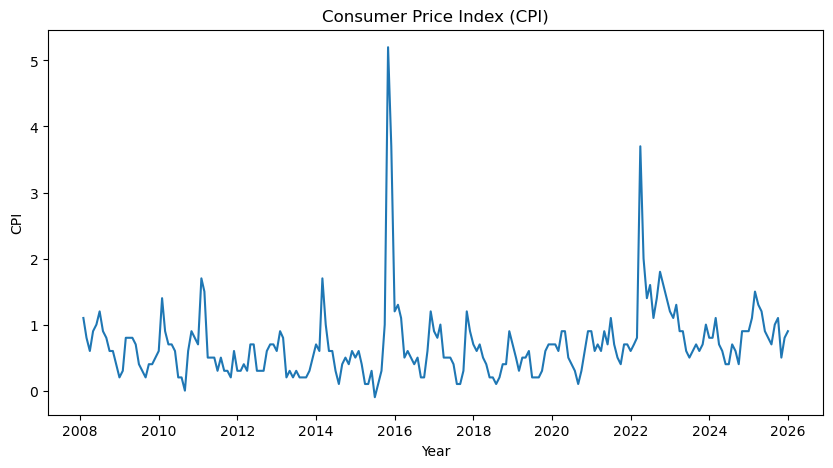

In [14]:
plt.figure(figsize=(10,5))

plt.plot(data["cpi"])

plt.title("Consumer Price Index (CPI)")

plt.xlabel("Year")

plt.ylabel("CPI")

plt.show()

# Stationarity Test

Before applying the ARIMA model, it is necessary to test whether the time series is stationary.

In [15]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data["cpi"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -6.18169146600909
p-value: 6.432153861332531e-08


# ACF and PACF Analysis

Autocorrelation and partial autocorrelation plots help determine the appropriate ARIMA parameters.

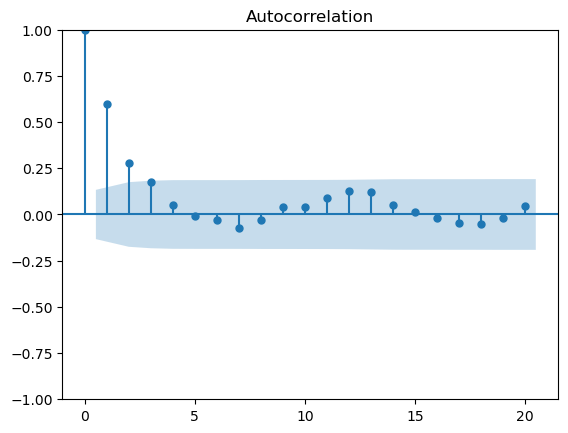

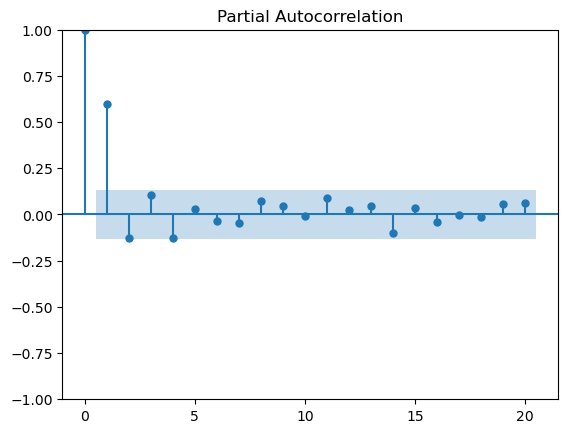

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(data["cpi"], lags=20)

plot_pacf(data["cpi"], lags=20)

plt.show()

# ARIMA Model

The ARIMA (AutoRegressive Integrated Moving Average) model is used to model and forecast the CPI time series.

The model captures temporal dependencies in the inflation data and allows forecasting future CPI values based on historical observations.

In [17]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(data["cpi"], order=(1,0,1))

results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                    cpi   No. Observations:                  216
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -130.900
Date:                Fri, 06 Mar 2026   AIC                            269.801
Time:                        16:14:35   BIC                            283.302
Sample:                    01-31-2008   HQIC                           275.255
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6998      0.112      6.264      0.000       0.481       0.919
ar.L1          0.3861      0.098      3.929      0.000       0.193       0.579
ma.L1          0.3303      0.092      3.577      0.0

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


# ARIMA Model Results

The ARIMA model was estimated to analyze the temporal structure of the CPI time series.

The estimated coefficients indicate the presence of autoregressive and moving average components in inflation dynamics.

The model provides a statistical representation of inflation behavior over time.

# CPI Forecast

Using the fitted ARIMA model, future CPI values are forecasted for the next 12 months.

In [18]:
forecast = results.forecast(steps=12)

forecast

2026-01-31    0.796211
2026-02-28    0.737047
2026-03-31    0.714204
2026-04-30    0.705385
2026-05-31    0.701980
2026-06-30    0.700665
2026-07-31    0.700157
2026-08-31    0.699961
2026-09-30    0.699886
2026-10-31    0.699856
2026-11-30    0.699845
2026-12-31    0.699841
Freq: ME, Name: predicted_mean, dtype: float64

# CPI Forecast Interpretation

The ARIMA model forecasts CPI values for the next 12 months beyond the available dataset.

Since the historical data ends in December 2025, the model produces forecasts for the period from January 2026 to December 2026.

The results suggest that inflation stabilizes around 0.7% per month according to the ARIMA model.

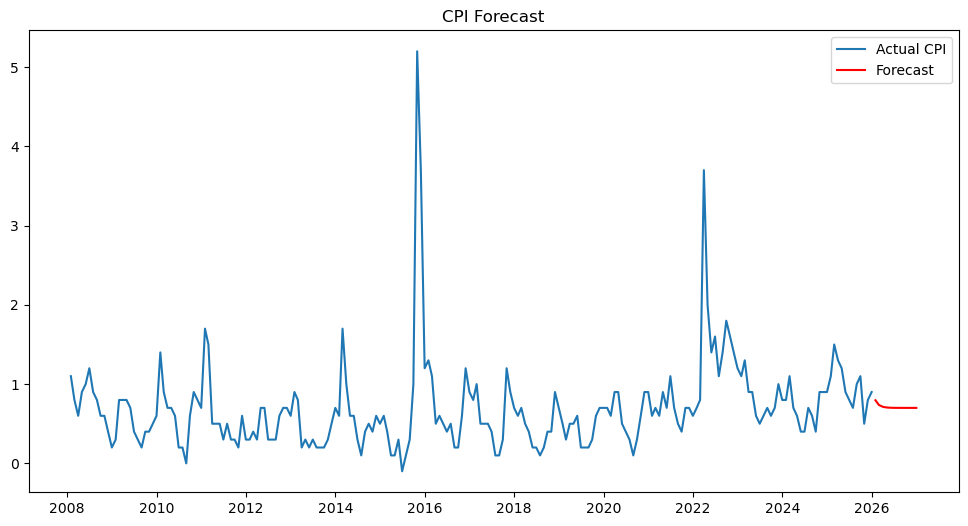

In [19]:
plt.figure(figsize=(12,6))

plt.plot(data["cpi"], label="Actual CPI")

plt.plot(forecast, color="red", label="Forecast")

plt.legend()

plt.title("CPI Forecast")

plt.show()

# CPI Forecast Visualization

The following figure shows the historical CPI values together with the forecast generated by the ARIMA model.

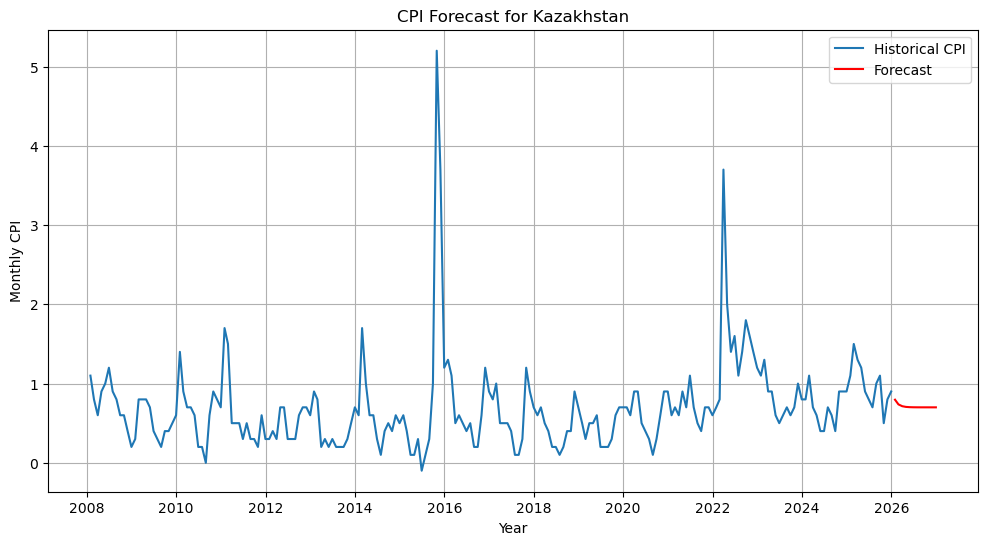

In [20]:
plt.figure(figsize=(12,6))

plt.plot(data.index, data["cpi"], label="Historical CPI")

plt.plot(forecast.index, forecast, color="red", label="Forecast")

plt.title("CPI Forecast for Kazakhstan")

plt.xlabel("Year")
plt.ylabel("Monthly CPI")

plt.legend()

plt.grid(True)

plt.show()

# Model Diagnostics

After estimating the ARIMA model, it is important to analyze the residuals to ensure that the model adequately captures the dynamics of the CPI series.

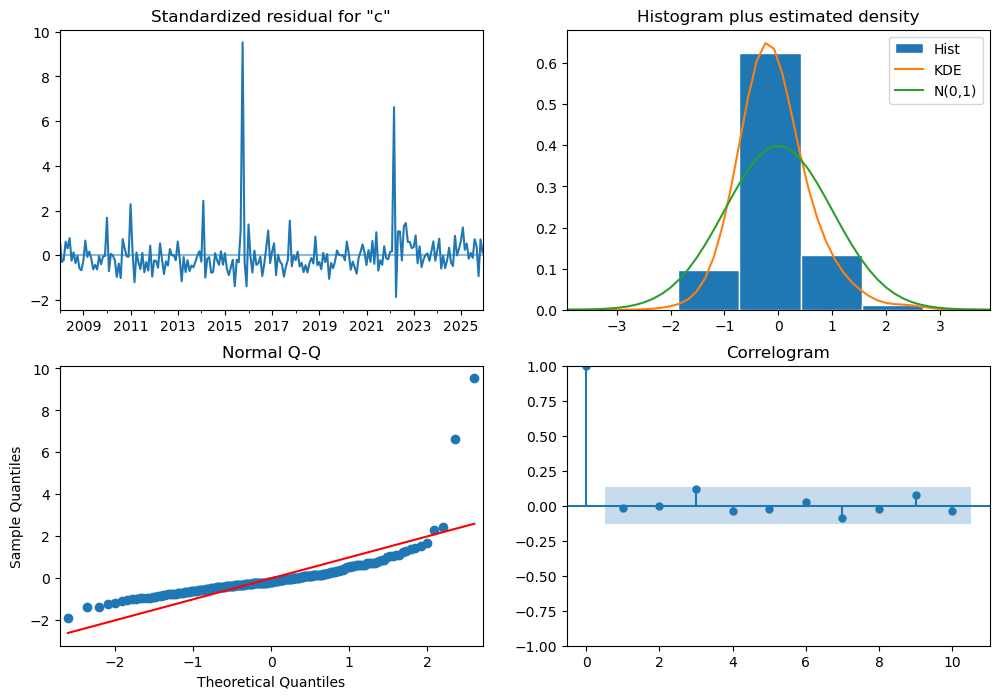

In [21]:
results.plot_diagnostics(figsize=(12,8))

plt.show()

In [22]:
plt.savefig("cpi_forecast.png", dpi=300)

<Figure size 640x480 with 0 Axes>

# SARIMA Model

To capture seasonal patterns in inflation dynamics, the SARIMA model is applied.

In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    data["cpi"],
    order=(1,0,1),
    seasonal_order=(1,0,1,12)
)

sarima_results = sarima_model.fit()

print(sarima_results.summary())

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                                cpi   No. Observations:                  216
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -141.017
Date:                            Fri, 06 Mar 2026   AIC                            292.033
Time:                                    16:14:37   BIC                            308.910
Sample:                                01-31-2008   HQIC                           298.852
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6006      0.055     10.920      0.000       0.493       0.708
ma.L1          0.1204      0.080   

In [24]:
sarima_forecast = sarima_results.forecast(steps=12)

sarima_forecast

2026-01-31    0.881100
2026-02-28    0.897644
2026-03-31    0.834398
2026-04-30    0.707984
2026-05-31    0.550088
2026-06-30    0.474638
2026-07-31    0.408547
2026-08-31    0.420884
2026-09-30    0.513619
2026-10-31    0.759310
2026-11-30    0.814044
2026-12-31    0.657117
Freq: ME, Name: predicted_mean, dtype: float64

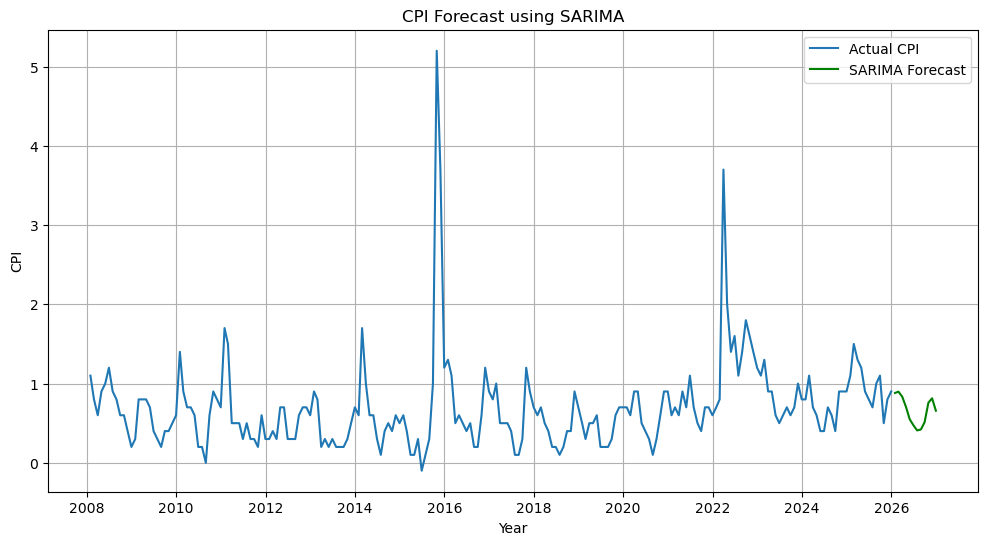

In [25]:
plt.figure(figsize=(12,6))

plt.plot(data.index, data["cpi"], label="Actual CPI")

plt.plot(sarima_forecast.index, sarima_forecast,
         color="green", label="SARIMA Forecast")

plt.title("CPI Forecast using SARIMA")

plt.xlabel("Year")
plt.ylabel("CPI")

plt.legend()
plt.grid(True)

plt.show()

# ARIMAX Model

To incorporate macroeconomic factors into the inflation model, the ARIMAX model is estimated using oil prices and exchange rates as exogenous variables.

In [26]:
exog = data[["oil_price", "usd_kzt"]]

arimax_model = SARIMAX(
    data["cpi"],
    exog=exog,
    order=(1,0,1)
)

arimax_results = arimax_model.fit()

print(arimax_results.summary())

                               SARIMAX Results                                
Dep. Variable:                    cpi   No. Observations:                  216
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -126.460
Date:                Fri, 06 Mar 2026   AIC                            262.920
Time:                        16:14:37   BIC                            279.796
Sample:                    01-31-2008   HQIC                           269.738
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
oil_price      0.0040      0.002      1.976      0.048    3.32e-05       0.008
usd_kzt        0.0013      0.001      2.497      0.013       0.000       0.002
ar.L1          0.4080      0.094      4.350      0.0

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [27]:
arimax_forecast = arimax_results.forecast(
    steps=12,
    exog=exog.iloc[-12:]
)

arimax_forecast

2026-01-31    0.990143
2026-02-28    0.960200
2026-03-31    0.940014
2026-04-30    0.941718
2026-05-31    0.928017
2026-06-30    0.954389
2026-07-31    0.971664
2026-08-31    0.976213
2026-09-30    0.979645
2026-10-31    0.964121
2026-11-30    0.940027
2026-12-31    0.918684
Freq: ME, Name: predicted_mean, dtype: float64

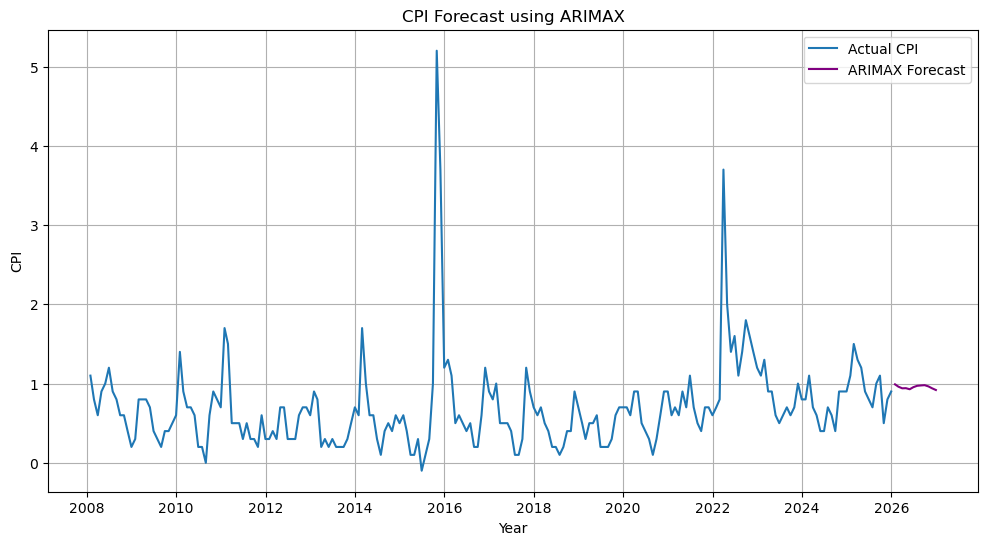

In [28]:
plt.figure(figsize=(12,6))

plt.plot(data.index, data["cpi"], label="Actual CPI")

plt.plot(arimax_forecast.index, arimax_forecast,
         color="purple", label="ARIMAX Forecast")

plt.title("CPI Forecast using ARIMAX")

plt.xlabel("Year")
plt.ylabel("CPI")

plt.legend()
plt.grid(True)

plt.show()

In [29]:
arima_forecast = results.forecast(steps=12)

arima_forecast

2026-01-31    0.796211
2026-02-28    0.737047
2026-03-31    0.714204
2026-04-30    0.705385
2026-05-31    0.701980
2026-06-30    0.700665
2026-07-31    0.700157
2026-08-31    0.699961
2026-09-30    0.699886
2026-10-31    0.699856
2026-11-30    0.699845
2026-12-31    0.699841
Freq: ME, Name: predicted_mean, dtype: float64

In [30]:
sarima_forecast = sarima_results.forecast(steps=12)

sarima_forecast

2026-01-31    0.881100
2026-02-28    0.897644
2026-03-31    0.834398
2026-04-30    0.707984
2026-05-31    0.550088
2026-06-30    0.474638
2026-07-31    0.408547
2026-08-31    0.420884
2026-09-30    0.513619
2026-10-31    0.759310
2026-11-30    0.814044
2026-12-31    0.657117
Freq: ME, Name: predicted_mean, dtype: float64

In [31]:
future_exog = data[["oil_price","usd_kzt"]].iloc[-12:]

arimax_forecast = arimax_results.forecast(
    steps=12,
    exog=future_exog
)

arimax_forecast

2026-01-31    0.990143
2026-02-28    0.960200
2026-03-31    0.940014
2026-04-30    0.941718
2026-05-31    0.928017
2026-06-30    0.954389
2026-07-31    0.971664
2026-08-31    0.976213
2026-09-30    0.979645
2026-10-31    0.964121
2026-11-30    0.940027
2026-12-31    0.918684
Freq: ME, Name: predicted_mean, dtype: float64

In [32]:
forecast_table = pd.DataFrame({

    "ARIMA": arima_forecast,
    "SARIMA": sarima_forecast,
    "ARIMAX": arimax_forecast

})

forecast_table

,ARIMA,SARIMA,ARIMAX
2026-01-31,0.796211,0.881100,0.990143
2026-02-28,0.737047,0.897644,0.960200
2026-03-31,0.714204,0.834398,0.940014
2026-04-30,0.705385,0.707984,0.941718
2026-05-31,0.701980,0.550088,0.928017
2026-06-30,0.700665,0.474638,0.954389
2026-07-31,0.700157,0.408547,0.971664
2026-08-31,0.699961,0.420884,0.976213
2026-09-30,0.699886,0.513619,0.979645
2026-10-31,0.699856,0.759310,0.964121


# Forecast Comparison

To evaluate the predictive performance of different time-series models, forecasts were generated using ARIMA, SARIMA, and ARIMAX models.

The forecast table presents predicted CPI values for the next 12 months. These models incorporate both historical inflation dynamics and macroeconomic variables such as oil prices and exchange rates.


In [33]:
data.head()

,oil_price,usd_kzt,cpi
Date,,,
2008-01-31,92.091739,120.352258,1.1
2008-02-29,94.722381,120.322414,0.8
2008-03-31,103.161905,120.644194,0.6
2008-04-30,110.033182,120.510333,0.9
2008-05-31,123.862273,120.551290,1.0


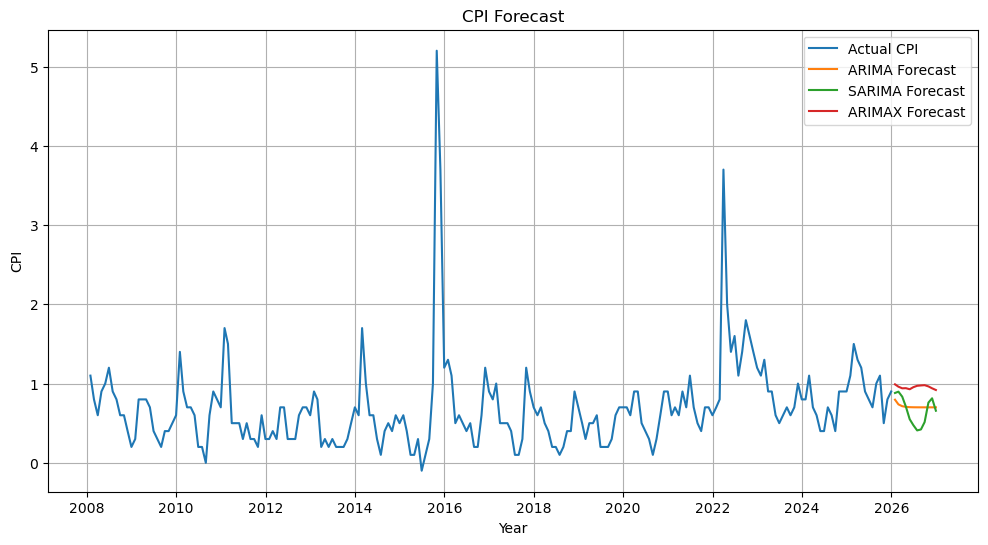

In [34]:
plt.figure(figsize=(12,6))

plt.plot(data.index, data["cpi"], label="Actual CPI")

plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast")
plt.plot(sarima_forecast.index, sarima_forecast, label="SARIMA Forecast")
plt.plot(arimax_forecast.index, arimax_forecast, label="ARIMAX Forecast")

plt.legend()

plt.title("CPI Forecast")

plt.xlabel("Year")
plt.ylabel("CPI")

plt.grid(True)

plt.show()

# Feature Engineering for Machine Learning Models

To apply machine learning models, lagged variables of CPI are created.
These lag features allow the models to capture temporal dependencies in inflation dynamics.

In [35]:
data_ml = data.copy()

data_ml["cpi_lag1"] = data_ml["cpi"].shift(1)
data_ml["cpi_lag2"] = data_ml["cpi"].shift(2)
data_ml["cpi_lag3"] = data_ml["cpi"].shift(3)

data_ml = data_ml.dropna()

data_ml.head()

,oil_price,usd_kzt,cpi,cpi_lag1,cpi_lag2,cpi_lag3
Date,,,,,,
2008-04-30,110.033182,120.510333,0.9,0.6,0.8,1.1
2008-05-31,123.862273,120.551290,1.0,0.9,0.6,0.8
2008-06-30,132.760476,120.695667,1.2,1.0,0.9,0.6
2008-07-31,133.585217,120.296774,0.9,1.2,1.0,0.9
2008-08-31,113.800476,119.993871,0.8,0.9,1.2,1.0


# Train-Test Split

The dataset is divided into training and testing sets.
The last 20% of observations are used for out-of-sample evaluation.

In [36]:
from sklearn.model_selection import train_test_split

features = ["oil_price", "usd_kzt", "cpi_lag1", "cpi_lag2", "cpi_lag3"]

X = data_ml[features]
y = data_ml["cpi"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

# Ridge Regression Model

Ridge regression is a regularized linear model that helps prevent overfitting by penalizing large coefficients.

In [37]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

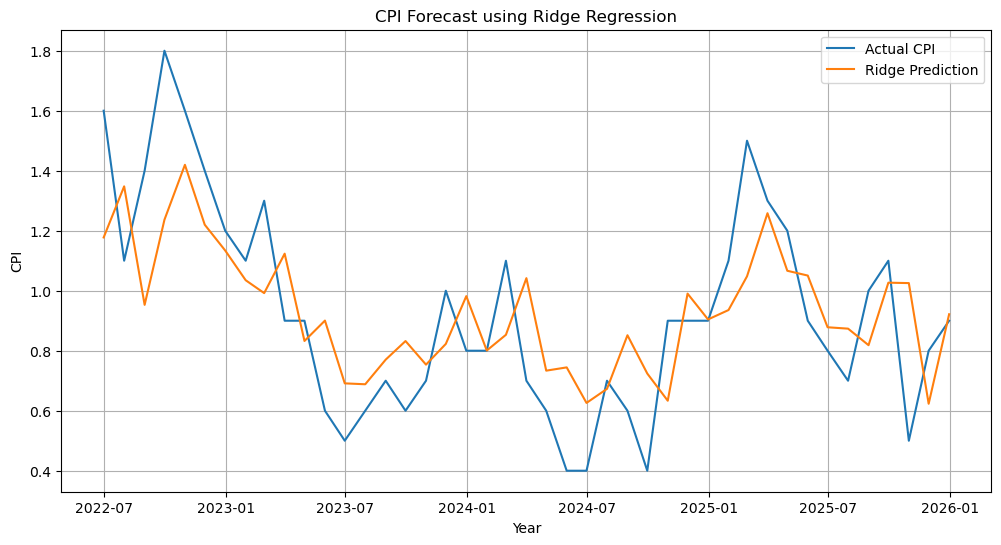

In [38]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual CPI")

plt.plot(y_test.index, ridge_pred,
         label="Ridge Prediction")

plt.title("CPI Forecast using Ridge Regression")

plt.xlabel("Year")
plt.ylabel("CPI")

plt.legend()
plt.grid(True)

plt.show()

# Lasso Regression Model

Lasso regression performs variable selection by shrinking some coefficients to zero.

In [39]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

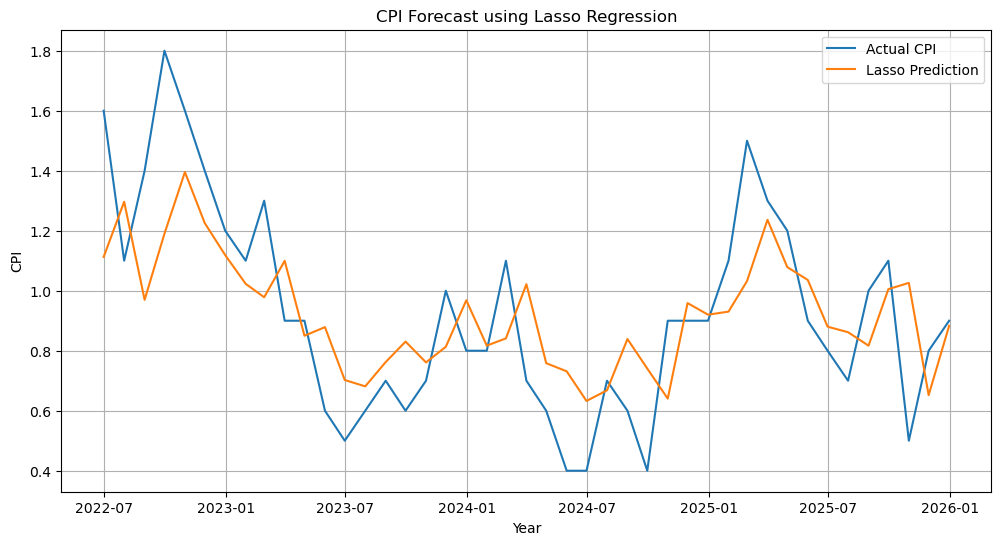

In [40]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual CPI")

plt.plot(y_test.index, lasso_pred,
         label="Lasso Prediction")

plt.title("CPI Forecast using Lasso Regression")

plt.xlabel("Year")
plt.ylabel("CPI")

plt.legend()
plt.grid(True)

plt.show()

# ElasticNet Model

ElasticNet combines L1 and L2 regularization and is useful when predictors are correlated.

In [41]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)

elastic.fit(X_train, y_train)

elastic_pred = elastic.predict(X_test)

# Random Forest Model

Random Forest is an ensemble learning method that builds multiple decision trees and averages their predictions.

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

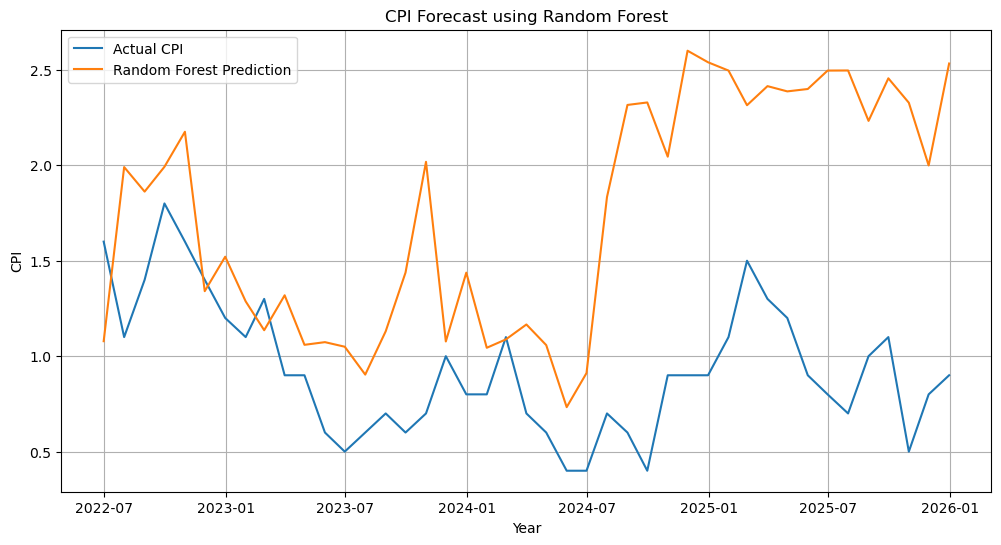

In [43]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual CPI")

plt.plot(y_test.index, rf_pred,
         label="Random Forest Prediction")

plt.title("CPI Forecast using Random Forest")

plt.xlabel("Year")
plt.ylabel("CPI")

plt.legend()
plt.grid(True)

plt.show()

# Gradient Boosting Model

Gradient Boosting sequentially builds decision trees to minimize prediction errors.

In [44]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

# XGBoost Model

XGBoost is an optimized gradient boosting algorithm widely used in forecasting and predictive modeling.

In [45]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [46]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [47]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

rmse

np.float64(1.0862118405833854)

# Naive Forecast Model

The naive model is used as a baseline benchmark.  
It assumes that the next value of CPI will be equal to the most recent observed value.

This model is commonly used in time series forecasting to evaluate whether more complex models provide improvements over a simple persistence forecast.

In [48]:
naive_pred = y_test.shift(1)

In [49]:
naive_pred = y_test.shift(1).dropna()
y_test_naive = y_test.iloc[1:]

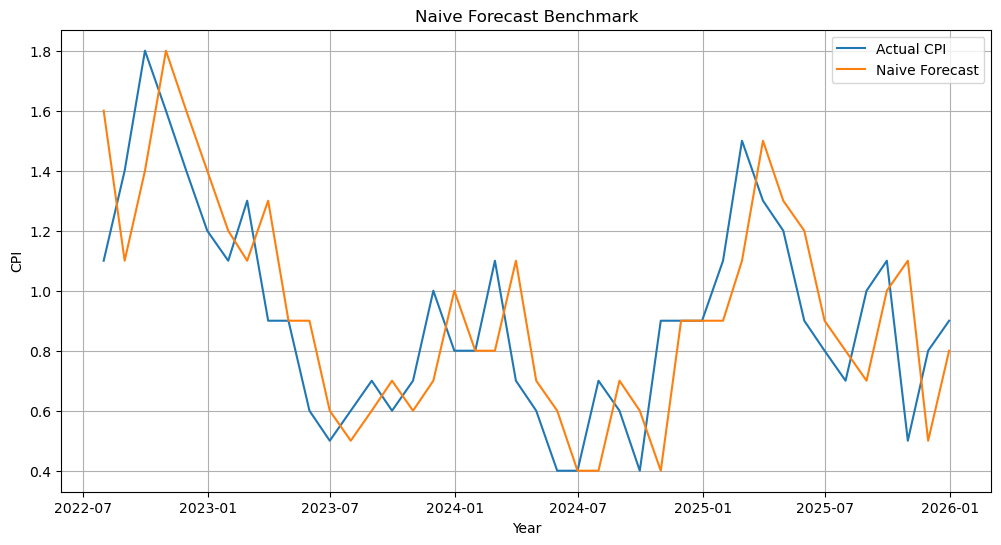

In [50]:
plt.figure(figsize=(12,6))

plt.plot(y_test_naive.index, y_test_naive, label="Actual CPI")

plt.plot(y_test_naive.index, naive_pred,
         label="Naive Forecast")

plt.title("Naive Forecast Benchmark")

plt.xlabel("Year")
plt.ylabel("CPI")

plt.legend()
plt.grid(True)

plt.show()

In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

naive_rmse = np.sqrt(mean_squared_error(y_test_naive, naive_pred))

naive_mae = mean_absolute_error(y_test_naive, naive_pred)

naive_r2 = r2_score(y_test_naive, naive_pred)

print("Naive RMSE:", naive_rmse)
print("Naive MAE:", naive_mae)
print("Naive R2:", naive_r2)

Naive RMSE: 0.2540153726131735
Naive MAE: 0.20714285714285743
Naive R2: 0.4148673658235671


# Model Evaluation

To compare the forecasting performance of machine learning models, three evaluation metrics are used:

* **RMSE (Root Mean Squared Error)** – measures the average magnitude of prediction errors.
* **MAE (Mean Absolute Error)** – measures the average absolute difference between predicted and actual values.
* **R² (Coefficient of Determination)** – indicates how well the model explains the variance of the dependent variable.

Lower values of RMSE and MAE indicate better model performance, while higher values of R² indicate a better fit.


In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

results = pd.DataFrame({

    "Model":[
        "Ridge",
        "Lasso",
        "ElasticNet",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
        np.sqrt(mean_squared_error(y_test, elastic_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],

    "MAE":[
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, elastic_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],

    "R2":[
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, elastic_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred),
        r2_score(y_test, xgb_pred)
    ]

})

results

,Model,RMSE,MAE,R2
0,Ridge,0.241631,0.197590,0.506831
1,Lasso,0.244830,0.198687,0.493687
2,ElasticNet,0.246529,0.199923,0.486636
3,Random Forest,1.031886,0.851581,-7.994042
4,Gradient Boosting,1.360000,1.025273,-14.623169
5,XGBoost,1.086212,0.853106,-8.965985


# Machine Learning Model Evaluation

To evaluate the predictive performance of machine learning models, three evaluation metrics are used:

* RMSE (Root Mean Squared Error)
* MAE (Mean Absolute Error)
* R² (Coefficient of Determination)

These metrics allow comparison of the accuracy of different models in predicting CPI.


In [53]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

results_ml = pd.DataFrame({

    "Model":[
        "Naive",
        "Ridge",
        "Lasso",
        "ElasticNet",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test_naive, naive_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
        np.sqrt(mean_squared_error(y_test, elastic_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],

    "MAE":[
        mean_absolute_error(y_test_naive, naive_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, elastic_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],

    "R2":[
        r2_score(y_test_naive, naive_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, elastic_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred),
        r2_score(y_test, xgb_pred)
    ]

})

results_ml

,Model,RMSE,MAE,R2
0,Naive,0.254015,0.207143,0.414867
1,Ridge,0.241631,0.197590,0.506831
2,Lasso,0.244830,0.198687,0.493687
3,ElasticNet,0.246529,0.199923,0.486636
4,Random Forest,1.031886,0.851581,-7.994042
5,Gradient Boosting,1.360000,1.025273,-14.623169
6,XGBoost,1.086212,0.853106,-8.965985


In [54]:
results_ml.sort_values("RMSE")

,Model,RMSE,MAE,R2
1,Ridge,0.241631,0.197590,0.506831
2,Lasso,0.244830,0.198687,0.493687
3,ElasticNet,0.246529,0.199923,0.486636
0,Naive,0.254015,0.207143,0.414867
4,Random Forest,1.031886,0.851581,-7.994042
6,XGBoost,1.086212,0.853106,-8.965985
5,Gradient Boosting,1.360000,1.025273,-14.623169


# Forecast Visualization

To illustrate the forecasting performance, the predicted CPI values of the best-performing model are plotted against the actual CPI values.

This visualization helps evaluate how closely the model follows the observed inflation dynamics.


In [55]:
best_model = results_ml.loc[results_ml["RMSE"].idxmin()]

best_model

Model       Ridge
RMSE     0.241631
MAE       0.19759
R2       0.506831
Name: 1, dtype: object

In [56]:
results_ml.sort_values("RMSE")

,Model,RMSE,MAE,R2
1,Ridge,0.241631,0.197590,0.506831
2,Lasso,0.244830,0.198687,0.493687
3,ElasticNet,0.246529,0.199923,0.486636
0,Naive,0.254015,0.207143,0.414867
4,Random Forest,1.031886,0.851581,-7.994042
6,XGBoost,1.086212,0.853106,-8.965985
5,Gradient Boosting,1.360000,1.025273,-14.623169


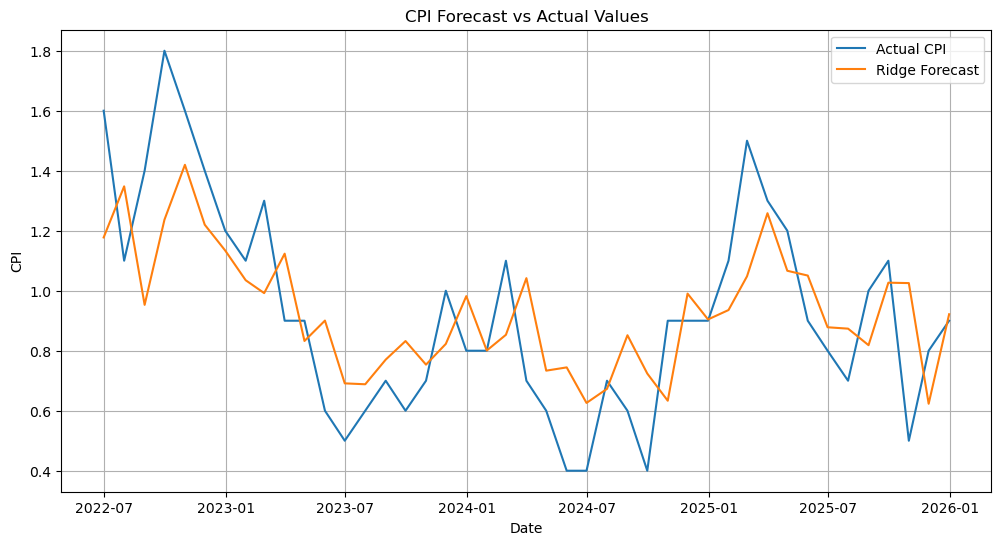

In [57]:
plt.figure(figsize=(12,6))

plt.plot(y_test.index, y_test, label="Actual CPI")

plt.plot(y_test.index, ridge_pred,
         label="Ridge Forecast")

plt.title("CPI Forecast vs Actual Values")

plt.xlabel("Date")
plt.ylabel("CPI")

plt.legend()
plt.grid(True)

plt.show()

# Model Performance Comparison

To identify the most accurate forecasting approach, the performance of all machine learning models is compared using RMSE, MAE, and R² metrics.

The models are ranked based on RMSE values, where lower values indicate better predictive accuracy.


In [58]:
results_ml_sorted = results_ml.sort_values("RMSE")

results_ml_sorted

,Model,RMSE,MAE,R2
1,Ridge,0.241631,0.197590,0.506831
2,Lasso,0.244830,0.198687,0.493687
3,ElasticNet,0.246529,0.199923,0.486636
0,Naive,0.254015,0.207143,0.414867
4,Random Forest,1.031886,0.851581,-7.994042
6,XGBoost,1.086212,0.853106,-8.965985
5,Gradient Boosting,1.360000,1.025273,-14.623169


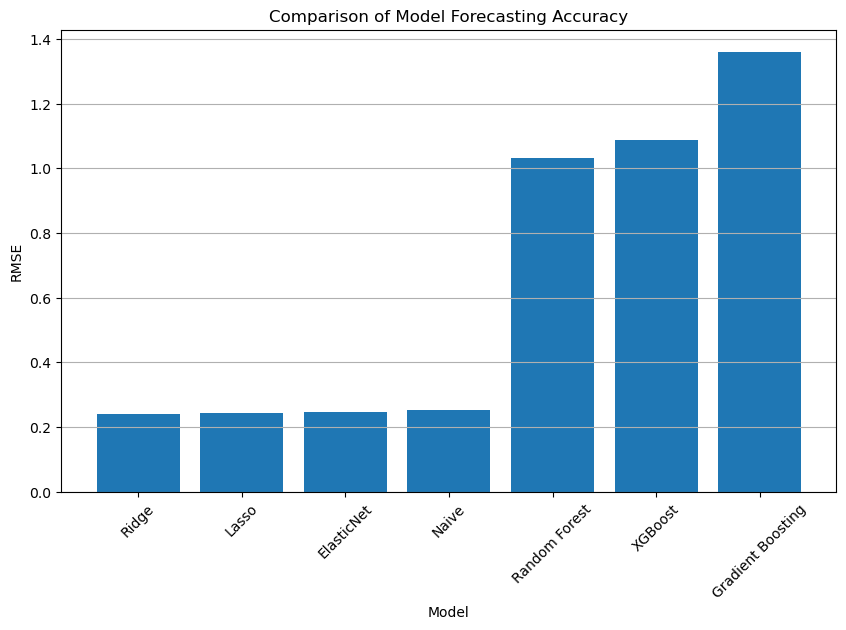

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(results_ml_sorted["Model"],
        results_ml_sorted["RMSE"])

plt.title("Comparison of Model Forecasting Accuracy")

plt.xlabel("Model")

plt.ylabel("RMSE")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()

# Neural Network Model

In addition to classical statistical models and machine learning algorithms, a neural network model was implemented to capture potential nonlinear relationships in the CPI time series.


In [61]:
from sklearn.neural_network import MLPRegressor

nn = MLPRegressor(
    hidden_layer_sizes=(64,32),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

nn.fit(X_train, y_train)

nn_pred = nn.predict(X_test)

In [62]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

nn_rmse = np.sqrt(mean_squared_error(y_test, nn_pred))
nn_mae = mean_absolute_error(y_test, nn_pred)
nn_r2 = r2_score(y_test, nn_pred)

nn_rmse, nn_mae, nn_r2

(np.float64(2.8243706613812067), 2.729856828885448, -66.38054705883202)

In [63]:
results.loc[len(results)] = [
    "Neural Network",
    nn_rmse,
    nn_mae,
    nn_r2
]

results

,Model,RMSE,MAE,R2
0,Ridge,0.241631,0.197590,0.506831
1,Lasso,0.244830,0.198687,0.493687
2,ElasticNet,0.246529,0.199923,0.486636
3,Random Forest,1.031886,0.851581,-7.994042
4,Gradient Boosting,1.360000,1.025273,-14.623169
5,XGBoost,1.086212,0.853106,-8.965985
6,Neural Network,2.824371,2.729857,-66.380547
